In [8]:
# Install required libraries
!pip install pandas numpy scikit-learn joblib matplotlib seaborn

# Import necessary libraries
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset (Upload your 10,000 crop dataset)
from google.colab import files
uploaded = files.upload()

# Read the dataset
df = pd.read_csv(list(uploaded.keys())[0])

# Display first few rows
df.head()


Saving real_crop_growth_dataset.csv to real_crop_growth_dataset (1).csv


,Crop Name,Sprout Period (Days),Bloom Period (Days),Mature Period (Days),Total Growth Period (Days)
0,Coconut Organic Fast-Grow Local,14,79,81,174
1,Ginger Improved Dwarf Fast-Grow,17,42,90,149
2,Blueberry Hybrid Hybrid Improved Hybrid Organic,17,75,80,172
3,Rice Local Organic Local Hybrid,17,78,103,198
4,Strawberry Organic Local Dwarf Hybrid Dwarf Or...,11,82,70,163


In [10]:
# Check for missing values
df.isnull().sum()

# Convert categorical 'Crop Name' into numerical labels
df["Crop ID"] = df["Crop Name"].astype("category").cat.codes

# Select features & target
X = df[["Crop ID", "Sprout Period (Days)", "Bloom Period (Days)", "Mature Period (Days)"]]
y = df["Total Growth Period (Days)"]

# Split into training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# Initialize and train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


In [12]:
# Calculate accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🔹 Mean Absolute Error (MAE): {mae:.2f}")
print(f"🔹 Mean Squared Error (MSE): {mse:.2f}")
print(f"🔹 R² Score: {r2:.4f}")


🔹 Mean Absolute Error (MAE): 1.08
🔹 Mean Squared Error (MSE): 2.00
🔹 R² Score: 0.9981


In [13]:
# Convert total growth days into categories
def categorize_growth(days):
    if days <= 100:
        return "Short Growth"
    elif 101 <= days <= 200:
        return "Medium Growth"
    else:
        return "Long Growth"

df["Growth Category"] = df["Total Growth Period (Days)"].apply(categorize_growth)

# Convert categories to numeric labels
df["Growth Category"] = df["Growth Category"].astype("category").cat.codes

# Update target variable
y_class = df["Growth Category"]

# Split data for classification
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)



🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       253
           1       0.99      1.00      0.99       747

    accuracy                           0.99      1000
   macro avg       0.99      0.98      0.98      1000
weighted avg       0.99      0.99      0.99      1000



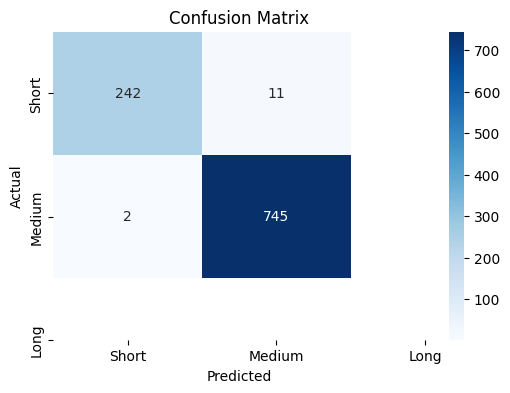

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict classes
y_pred_class = clf.predict(X_test)

# Classification report
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred_class))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Short", "Medium", "Long"], yticklabels=["Short", "Medium", "Long"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
